In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import csv

In [84]:
def get_name(name):
    match name:
        case 'baseline_customer_psql': return 'Baseline (PrivateSQL)'
        case 'baseline_customer': return 'Baseline (Ours)'
        case 'model1': return '$P^1_{R_1}$'
        case 'model2': return '$P^2_{R_1}$'
        case 'model3': return '$P^3_{R_1}$'
        case 'model4': return '$P^4_{R_1}$'
        case name: return f'Policy {name[-1]}'

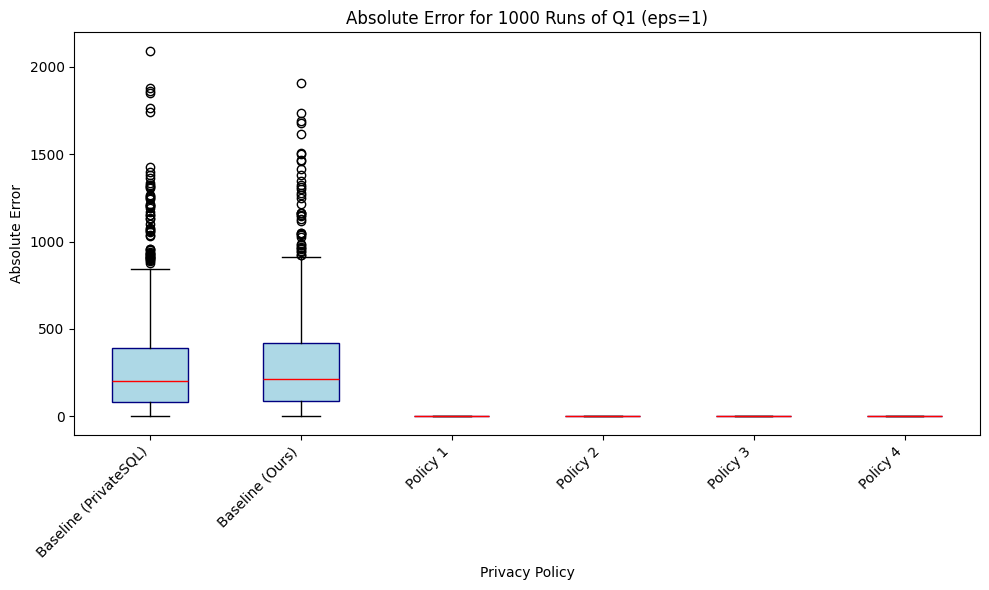

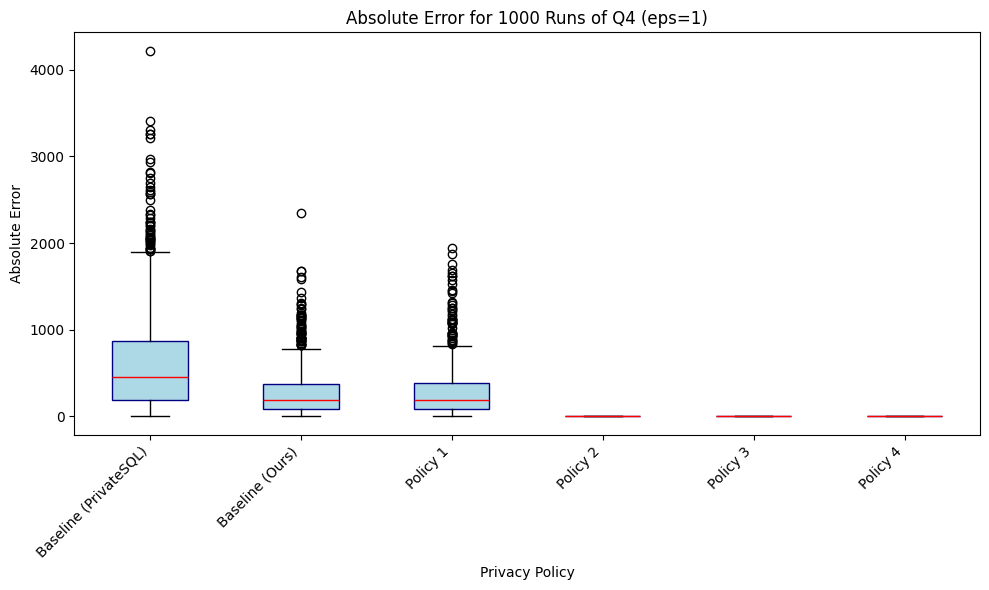

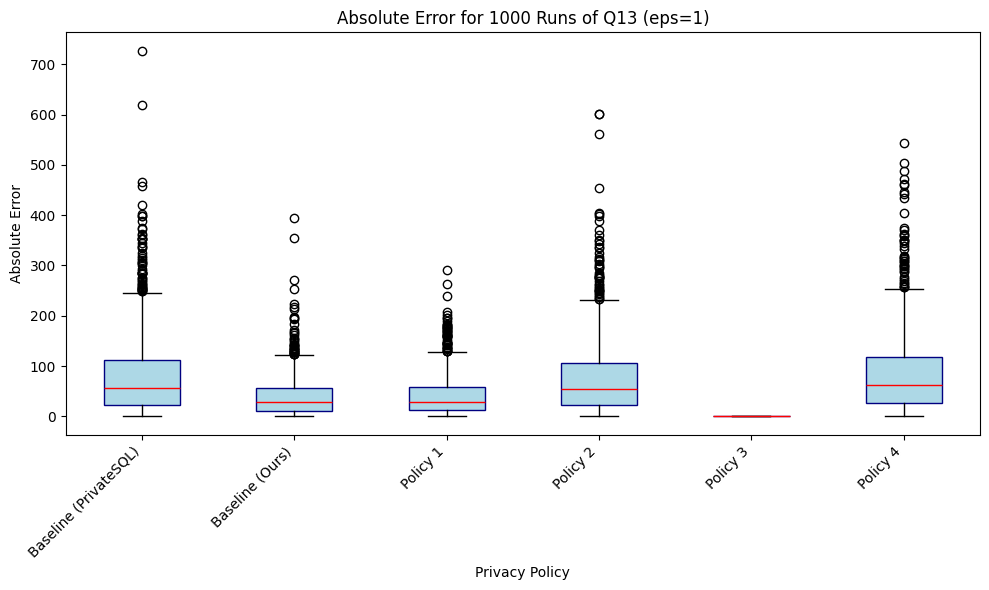

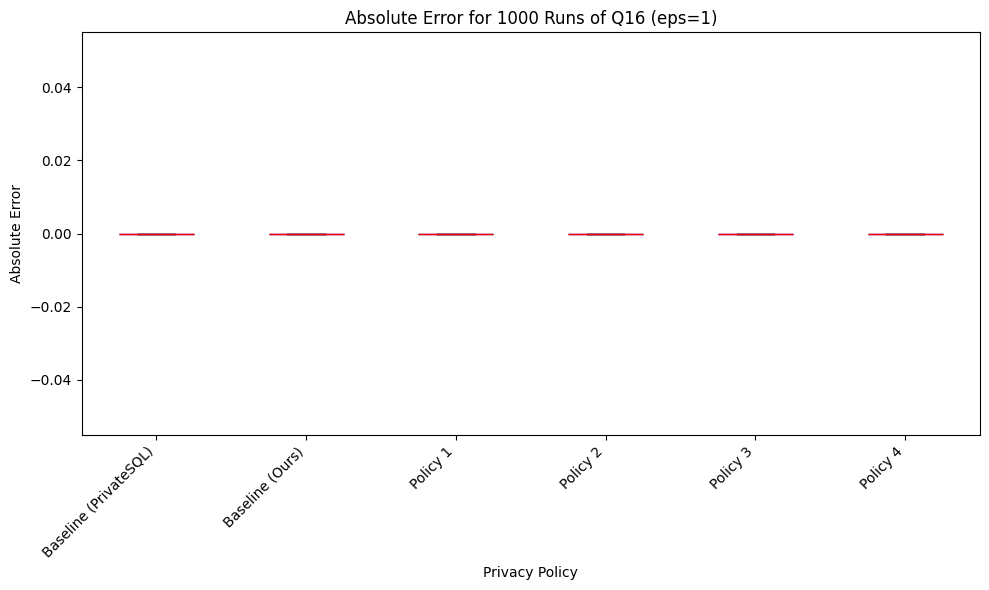

In [6]:
queries = [1, 4, 13, 16]

for query in queries:
    file = f'tpch_q{query}.csv'
    names = []
    data = []
    
    with open(file, newline='') as f:
        reader = csv.reader(f)
        for row in reader:
            if not row:
                continue
            names.append(get_name(row[0]))
            values = np.array(row[1:], dtype=float)
            data.append(values)
    
    data = np.array(data)
    
    plt.figure(figsize=(10, 6))
    plt.boxplot(
        data.T,
        tick_labels=names,
        patch_artist=True,
        boxprops=dict(facecolor="lightblue", color="navy"),
        medianprops=dict(color="red")
    )
    
    plt.title(f'Absolute Error for 1000 Runs of Q{query} (eps=1)')
    plt.xlabel("Privacy Policy")
    plt.ylabel("Absolute Error")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()

/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_10533/81334385.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Pastel2', len(queries))


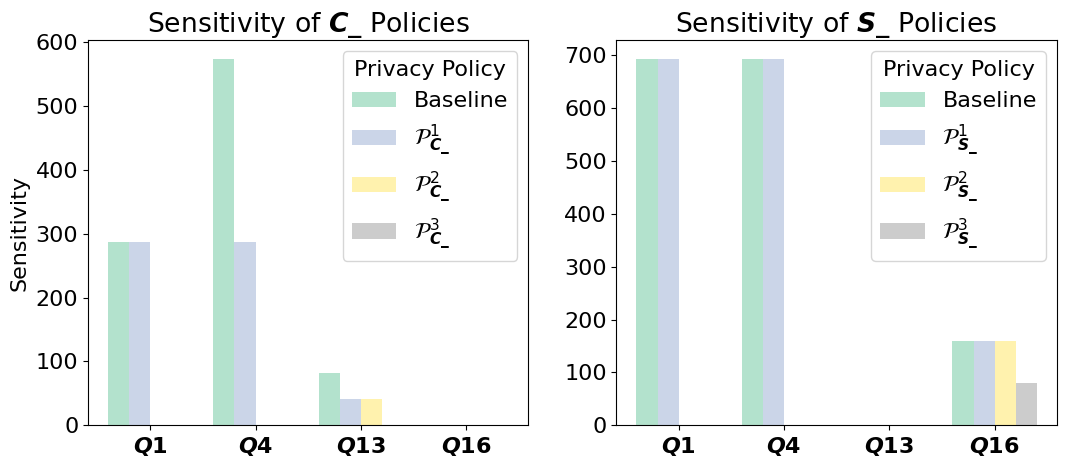

In [83]:
plt.rcParams.update({'font.size': 16}) # Sets the default font size to 14

policies = ['Baseline', r'$\mathcal{P}^1_{\boldsymbol{C\_}}$', r'$\mathcal{P}^2_{\boldsymbol{C\_}}$', r'$\mathcal{P}^3_{\boldsymbol{C\_}}$']
queries = [r'$\boldsymbol{Q1}$', r'$\boldsymbol{Q4}$', r'$\boldsymbol{Q13}$', r'$\boldsymbol{Q16}$']

cmap = cm.get_cmap('Pastel2', len(queries))

n_groups = 4
n_subgroups = 4

# Example data: 4 subgroups for each of the 4 main groups
data = np.array([
    [287, 287, 0, 0],
    [574, 287, 0, 0],
    [82, 41, 41, 0],
    [0, 0, 0, 0]
])

# X locations for groups
x = np.arange(n_groups)

# Bar width
bar_width = 0.2

# Create the plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 5))

# Plot each subgroup as a separate bar
for i in range(n_subgroups):
    ax1.bar(x + i * bar_width, data[:, i], width=bar_width, label=policies[i], color=cmap(i))

# Add labels and formatting
ax1.set_title(r'Sensitivity of $\boldsymbol{C\_}$ Policies')
ax1.set_ylabel('Sensitivity')
ax1.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax1.set_xticklabels(queries)
ax1.legend(title='Privacy Policy', ncol=1, loc='upper right')

policies = ['Baseline', r'$\mathcal{P}^1_{\boldsymbol{S\_}}$', r'$\mathcal{P}^2_{\boldsymbol{S\_}}$', r'$\mathcal{P}^3_{\boldsymbol{S\_}}$']

# Example data: 4 subgroups for each of the 4 main groups
data = np.array([
    [694, 694, 0, 0],
    [694, 694, 0, 0],
    [0, 0, 0, 0],
    [160, 160, 160, 80]
])

# Plot each subgroup as a separate bar
for i in range(n_subgroups):
    ax2.bar(x + i * bar_width, data[:, i], width=bar_width, label=policies[i], color=cmap(i))

# Add labels and formatting
ax2.set_title(r'Sensitivity of $\boldsymbol{S\_}$ Policies')
ax2.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax2.set_xticklabels(queries)
ax2.legend(title='Privacy Policy', ncol=1, loc='upper right')

/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_57155/813160821.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Pastel2', len(queries))


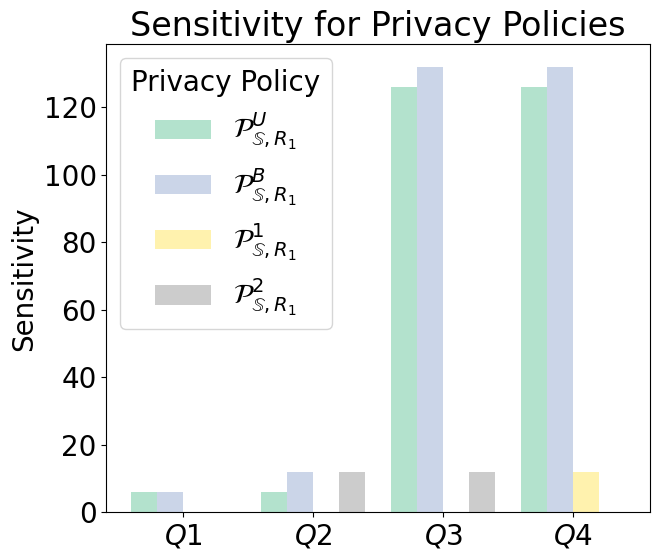

In [29]:
plt.rcParams.update({'font.size': 20}) # Sets the default font size to 14

policies = [r'$\mathcal{P}^U_{\mathbb{S},R_1}$', r'$\mathcal{P}^B_{\mathbb{S},R_1}$', r'$\mathcal{P}^1_{\mathbb{S},R_1}$', r'$\mathcal{P}^2_{\mathbb{S},R_1}$']
queries = ['$Q1$', '$Q2$', '$Q3$', '$Q4$']
cmap = cm.get_cmap('Pastel2', len(queries))

n_groups = 4
n_subgroups = 4

# Example data: 4 subgroups for each of the 4 main groups
data = np.array([
    [6, 6, 0, 0],
    [6, 12, 0, 12],
    [126, 132, 0, 12],
    [126, 132, 12, 0]
])

# X locations for groups
x = np.arange(n_groups)

# Bar width
bar_width = 0.2

# Create the plot
fig, ax = plt.subplots(figsize=(7, 6))

# Plot each subgroup as a separate bar
for i in range(n_subgroups):
    ax.bar(x + i * bar_width, data[:, i], width=bar_width, label=policies[i], color=cmap(i))

# Add labels and formatting
ax.set_title('Sensitivity for Privacy Policies')
ax.set_ylabel('Sensitivity')
ax.set_xticks(x + bar_width * (n_subgroups - 1) / 2)
ax.set_xticklabels(queries)
ax.legend(title='Privacy Policy', ncol=1, loc='upper left')

plt.tight_layout()
plt.show()


/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_28722/2982925706.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Pastel2', len(queries))


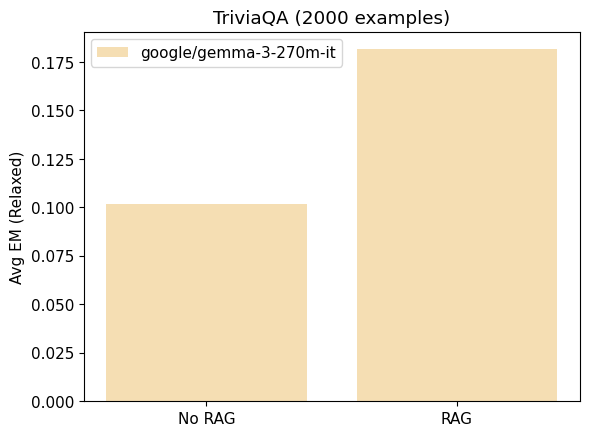

In [13]:
plt.rcParams.update({'font.size':11}) # Sets the default font size to 14

policies = [r'$\mathcal{P}^1_{R_1}$', r'$\mathcal{P}^2_{R_1}$', r'$\mathcal{P}^3_{R_1}$', r'$\mathcal{P}^4_{R_1}$']
queries = ['$Q1$', '$Q2$', '$Q3^{SUM}$', '$Q3^{CNT}$']
cmap = cm.get_cmap('Pastel2', len(queries))

n_groups = 4
n_subgroups = 4

# Example data: 4 subgroups for each of the 4 main groups
data = [0.1015, 0.1815]

# X locations for groups
x = np.arange(n_groups)

# Bar width
bar_width = 0.2

plt.bar(['No RAG', 'RAG'], data, color='wheat')
plt.title('TriviaQA (2000 examples)')
plt.ylabel('Avg EM (Relaxed)')
plt.legend(['google/gemma-3-270m-it'], loc='upper left')

plt.show()


In [7]:
queries = [3, 4]
data = []
names = []
    
with open('university_q3.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        names.append(get_name(row[0]))
        values = np.array(row[1:], dtype=float)
        data.append(values)

with open('university_q4.csv', newline='') as f:
    reader = csv.reader(f)
    for i, row in enumerate(reader):
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for j in range(len(data[i])):
            if values[j] != 0:
                data[i][j] /= values[j]
            else:
                data[i][j] /= 60
    
data = np.array(data)
print(data)

plt.figure(figsize=(7, 6))
plt.boxplot(
    data.T,
    tick_labels=names,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="black"),
    medianprops=dict(color="red"),
    showfliers=False
)

plt.xlabel("Privacy Policy")
plt.ylabel("Absolute Error")
plt.tight_layout()

plt.show()

NameError: name 'get_name' is not defined

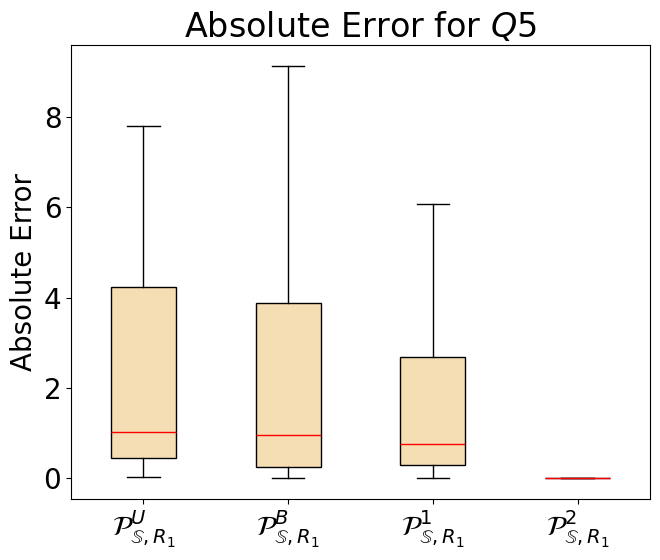

In [40]:
policies = [r'$\mathcal{P}^U_{\mathbb{S},R_1}$', r'$\mathcal{P}^B_{\mathbb{S},R_1}$', r'$\mathcal{P}^1_{\mathbb{S},R_1}$', r'$\mathcal{P}^2_{\mathbb{S},R_1}$']
data = []
    
with open('university/q5_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        data.append(values)

with open('university/q6_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for i in range(len(data)):
            for j in range(len(data[i])):
                data[i][j] /= (values[j] if values[j] != 0 else 1)
    
data = np.array(data)

plt.figure(figsize=(7, 6))
plt.boxplot(
    data.T,
    tick_labels=policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=False,
)

plt.title('Absolute Error for $Q5$')
plt.ylabel("Absolute Error")
plt.tight_layout()

plt.show()

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_10533/3232190030.py:3: SyntaxWarning: invalid escape sequence '\m'
  policies = ['Baseline', '$\mathcal{P}^1_{C\_}$', '$\mathcal{P}^2_{C\_}$', '$\mathcal{P}^3_{C\_}$']
/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_10533/3232190030.py:3: SyntaxWarning: invalid escape sequence '\m'
  policies = ['Baseline', '$\mathcal{P}^1_{C\_}$', '$\mathcal{P}^2_{C\_}$', '$\mathcal{P}^3_{C\_}$']
/var/folders/0g/gb022r0529d4_66pzmq9h2s80000gn/T/ipykernel_10533/3232190030.py:3: SyntaxWarning: invalid escape sequence '\m'
  policies = ['Baseline', '$\mathcal{P}^1_{C\_}$', '$\mathcal{P}^2_{C\_}$', '$\mathcal{P}^3_{C\_}$']


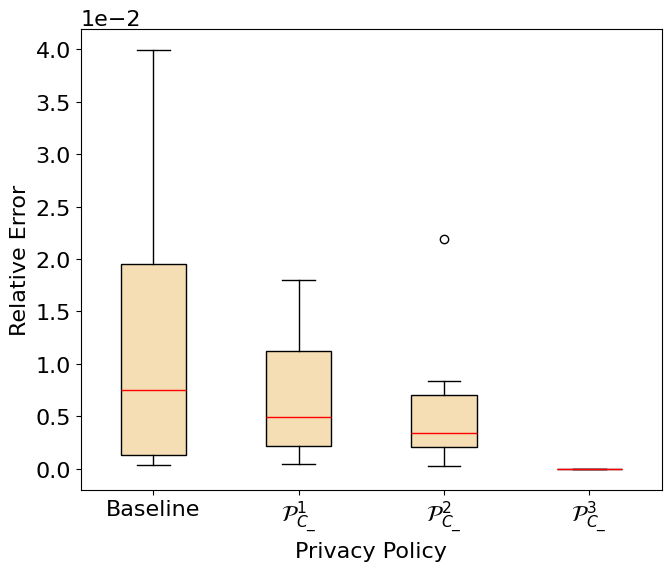

In [23]:
plt.rcParams.update({'font.size': 16}) # Sets the default font size to 14

policies = ['Baseline', '$\mathcal{P}^1_{C\_}$', '$\mathcal{P}^2_{C\_}$', '$\mathcal{P}^3_{C\_}$']
data = []
    
with open('tpch/q13_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for i in range(len(values)):
            values[i] /= 6641
        data.append(values)
    
data = np.array(data)

plt.figure(figsize=(7, 6))
plt.boxplot(
    data.T,
    tick_labels=policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)

plt.xlabel("Privacy Policy")
plt.ylabel("Relative Error")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()

plt.show()

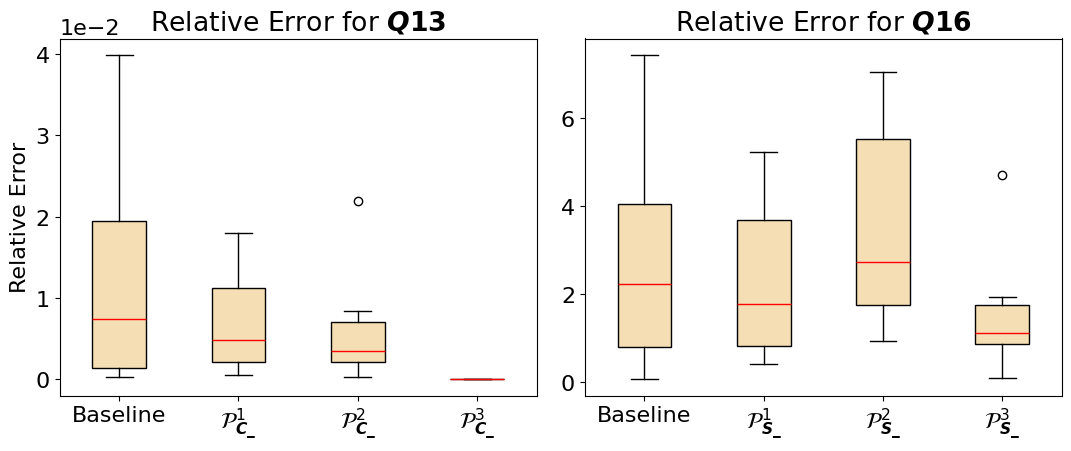

In [50]:
plt.rcParams.update({'font.size': 16}) # Sets the default font size to 14

policies = ['Baseline', r'$\mathcal{P}^1_{\boldsymbol{C\_}}$', r'$\mathcal{P}^2_{\boldsymbol{C\_}}$', r'$\mathcal{P}^3_{\boldsymbol{C\_}}$']
data = []


    
with open('tpch/q13_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for i in range(len(values)):
            values[i] /= 6641
        data.append(values)
    
data = np.array(data)

plt.figure(figsize=(11, 5))
plt.subplot(1, 2, 1)
plt.boxplot(
    data.T,
    tick_labels=policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)

plt.title(r'Relative Error for $\boldsymbol{Q13}$')
plt.ylabel("Relative Error")
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

policies = ['Baseline', r'$\mathcal{P}^1_{\boldsymbol{S\_}}$', r'$\mathcal{P}^2_{\boldsymbol{S\_}}$', r'$\mathcal{P}^3_{\boldsymbol{S\_}}$']
data = []
    
with open('tpch/q16_noise.csv', newline='') as f:
    reader = csv.reader(f)
    for row in reader:
        if not row:
            continue
        values = np.array(row[1:], dtype=float)
        for i in range(len(values)):
            values[i] /= 50
        data.append(values)
    
data = np.array(data)

plt.subplot(1, 2, 2)
plt.boxplot(
    data.T,
    tick_labels=policies,
    patch_artist=True,
    boxprops=dict(facecolor="wheat", color="black"),
    medianprops=dict(color="red"),
    showfliers=True,
)

plt.title(r'Relative Error for $\boldsymbol{Q16}$')
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.tight_layout()

plt.show()